### Bank Churn Classification Model
#### by : Shivam Singh

In [1]:
# Import Data Manipulation Libraries
import pandas as pd
import numpy as np

# Import data visualization libaries
import matplotlib.pyplot as plt
import seaborn as sns

# Import Neccessory Libraries
# 1 . Importing filter warning libraries
import warnings
warnings.filterwarnings(action= 'ignore')

# 2. Importing Data logging Libraries
import logging
logging.basicConfig(level=logging.INFO,
                    filename= 'model.log',
                    filemode='w',
                    format='%(asctime)s - %(levelname)s - %(message)s',
                    force = True)
#3. Import OrderDict()
from collections import OrderedDict

In [2]:
# Data ingestion 
df = pd.read_csv(r'C:\15Days15Project\Bank-Churn-Classification-Model\data\raw\Churn_Modelling.csv')

df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Descriptive stats

def descriptive_stats():
    numerical_col = df.select_dtypes(exclude = 'object').columns
    categorica_col = df.select_dtypes(include = 'object').columns
    num_stats = []
    cat_stats = []
    data_info = []

    for i in numerical_col:
        Q1 = df[i].quantile(0.25)
        Q3 = df[i].quantile(0.75)
        IQR = Q3 - Q1 
        LF = Q1 - 1.5*IQR
        UF = Q3 + 1.5*IQR

        outlier_count = len(df[(df[i] < LF) | (df[i] > UF)])
        outlier_percentage = outlier_count / len(df[i]) * 100

        numerical_stats = OrderedDict({
            "Feature " : i ,
            "Q1" : Q1,
            "Q3" : Q3,
            "IQR" : IQR,
            "LF" : LF,
            "UF" : UF,
            "Mean" : df[i].mean(),
            "Median" : df[i].median(),
            "Min" : df[i].min(),
            "Max" : df[i].max(),
            "Outlier count" : outlier_count,
            "outlier percentage" : outlier_percentage,
            "standard derivation": df[i].std(),
            "variance" : df[i].var(),
            "skewness" : df[i].skew(),
            "kurtosis" : df[i].kurtosis()
        })
        num_stats.append(numerical_stats)
    numerical_stats_report = pd.DataFrame(num_stats)

    for i in categorica_col:
        categorical_stats = OrderedDict({
            "Feature" : i , 
            "Unquie count" : df[i].nunique(),
            "Value count" : df[i].value_counts(),
            "mode" : df[i].mode()
        })
        cat_stats.append(categorical_stats)
    categorical_stats_report = pd.DataFrame(cat_stats)


    for i in df.columns : 
        data1 = OrderedDict({
            "Feature" : i ,
            "Missing value" : df[i].isnull().sum(),
            "Unqiue value" : df[i].nunique(),
            "value count " : df[i].value_counts().to_dict()
        })
        data_info.append(data1)
    data_info_report = pd.DataFrame(data_info)

    return categorical_stats_report,numerical_stats_report,data_info_report

categorical_stats_report,numerical_stats_report,data_info_report = descriptive_stats()

In [4]:
# Numerical Stats
numerical_stats_report

,Feature,Q1,Q3,IQR,LF,UF,Mean,Median,Min,Max,Outlier count,outlier percentage,standard derivation,variance,skewness,kurtosis
0,RowNumber,2500.75,7.500250e+03,4999.5000,-4.998500e+03,1.499950e+04,5.000500e+03,5.000500e+03,1.00,10000.00,0,0.00,2886.895680,8.334167e+06,0.000000,-1.200000
1,CustomerId,15628528.25,1.575323e+07,124705.5000,1.544147e+07,1.594029e+07,1.569094e+07,1.569074e+07,15565701.00,15815690.00,0,0.00,71936.186123,5.174815e+09,0.001149,-1.196113
2,CreditScore,584.00,7.180000e+02,134.0000,3.830000e+02,9.190000e+02,6.505288e+02,6.520000e+02,350.00,850.00,15,0.15,96.653299,9.341860e+03,-0.071607,-0.425726
3,Age,32.00,4.400000e+01,12.0000,1.400000e+01,6.200000e+01,3.892180e+01,3.700000e+01,18.00,92.00,359,3.59,10.487806,1.099941e+02,1.011320,1.395347
4,Tenure,3.00,7.000000e+00,4.0000,-3.000000e+00,1.300000e+01,5.012800e+00,5.000000e+00,0.00,10.00,0,0.00,2.892174,8.364673e+00,0.010991,-1.165225
5,Balance,0.00,1.276442e+05,127644.2400,-1.914664e+05,3.191106e+05,7.648589e+04,9.719854e+04,0.00,250898.09,0,0.00,62397.405202,3.893436e+09,-0.141109,-1.489412
6,NumOfProducts,1.00,2.000000e+00,1.0000,-5.000000e-01,3.500000e+00,1.530200e+00,1.000000e+00,1.00,4.00,60,0.60,0.581654,3.383218e-01,0.745568,0.582981
7,HasCrCard,0.00,1.000000e+00,1.0000,-1.500000e+00,2.500000e+00,7.055000e-01,1.000000e+00,0.00,1.00,0,0.00,0.455840,2.077905e-01,-0.901812,-1.186973
8,IsActiveMember,0.00,1.000000e+00,1.0000,-1.500000e+00,2.500000e+00,5.151000e-01,1.000000e+00,0.00,1.00,0,0.00,0.499797,2.497970e-01,-0.060437,-1.996747
9,EstimatedSalary,51002.11,1.493882e+05,98386.1375,-9.657710e+04,2.969675e+05,1.000902e+05,1.001939e+05,11.58,199992.48,0,0.00,57510.492818,3.307457e+09,0.002085,-1.181518


In [5]:
# Categorical stats
categorical_stats_report

,Feature,Unquie count,Value count,mode
0,Surname,2932,Surname Smith 32 Scott 29 Martin ...,"0 Smith Name: Surname, dtype: object"
1,Geography,3,Geography France 5014 Germany 2509 Spai...,"0 France Name: Geography, dtype: object"
2,Gender,2,Gender Male 5457 Female 4543 Name: cou...,"0 Male Name: Gender, dtype: object"


In [6]:
# Data info
data_info_report

,Feature,Missing value,Unqiue value,value count
0,RowNumber,0,10000,"{1: 1, 6671: 1, 6664: 1, 6665: 1, 6666: 1, 666..."
1,CustomerId,0,10000,"{15634602: 1, 15667932: 1, 15766185: 1, 156676..."
2,Surname,0,2932,"{'Smith': 32, 'Scott': 29, 'Martin': 29, 'Walk..."
3,CreditScore,0,460,"{850: 233, 678: 63, 655: 54, 705: 53, 667: 53,..."
4,Geography,0,3,"{'France': 5014, 'Germany': 2509, 'Spain': 2477}"
5,Gender,0,2,"{'Male': 5457, 'Female': 4543}"
6,Age,0,70,"{37: 478, 38: 477, 35: 474, 36: 456, 34: 447, ..."
7,Tenure,0,11,"{2: 1048, 1: 1035, 7: 1028, 8: 1025, 5: 1012, ..."
8,Balance,0,6382,"{0.0: 3617, 130170.82: 2, 105473.74: 2, 85304...."
9,NumOfProducts,0,4,"{1: 5084, 2: 4590, 3: 266, 4: 60}"


In [7]:
df.sample(frac = 1)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7234,7235,15624595,Chiang,512,Spain,Female,35,5,124580.69,1,1,1,18785.48,0
4851,4852,15618239,Neumann,530,France,Female,48,0,0.00,1,1,0,85081.09,0
6841,6842,15793491,Cherkasova,714,Germany,Male,26,3,119545.48,2,1,0,65482.94,0
2634,2635,15680278,Ts'ai,661,Spain,Female,42,9,75361.44,1,1,0,27608.12,1
2933,2934,15713144,Ingrassia,588,Spain,Male,46,8,0.00,1,1,0,61931.21,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8624,8625,15773639,Truscott,745,Germany,Male,35,4,98270.34,1,1,0,133617.43,0
8758,8759,15732621,Martin,663,France,Male,34,10,0.00,1,1,1,114083.73,0
2325,2326,15612193,Hsia,762,Spain,Male,29,10,115545.33,2,1,0,148256.43,0
8015,8016,15778694,Sievier,638,Germany,Female,26,1,105249.76,2,1,1,23491.09,0


In [8]:
# Crosstab Function Definition
def crosstab(df):
  crosstab1 = pd.crosstab(index = df['Geography'],columns = [df['Exited'],df['Tenure']],margins=True)
  crosstab2 = pd.crosstab(df['Age'],df['Exited'],margins = True)
  crosstab3 = pd.crosstab(df['Tenure'],df['Exited'],margins = True)
  crosstab4 = pd.crosstab(df['EstimatedSalary'],df['Exited'],margins = True)
  crosstab5 = pd.crosstab(df['HasCrCard'],df['Exited'],margins = True)

  return crosstab1,crosstab2,crosstab3,crosstab4,crosstab5

crosstab1,crosstab2,crosstab3,crosstab4,crosstab5 = crosstab(df)

In [9]:
# Crosstab reports
crosstab1.to_csv('crosstab1.csv')
crosstab1

Exited       0                                               ...    1       \
Tenure       0    1    2    3    4    5    6    7    8    9  ...    2    3   
Geography                                                    ...             
France     170  446  435  408  427  409  426  476  396  416  ...   90   83   
Germany     69  159  211  177  156  169  151  164  177  176  ...   64   84   
Spain       79  198  201  211  203  225  194  211  255  179  ...   47   46   
All        318  803  847  796  786  803  771  851  828  771  ...  201  213   

Exited                                          All  
Tenure       4    5    6    7    8    9   10         
Geography                                            
France      85   76   77   76   69   88   48   5014  
Germany     76   90   76   61   87   93   42   2509  
Spain       42   43   43   40   41   32   11   2477  
All        203  209  196  177  197  213  101  10000  

[4 rows x 23 columns]

In [10]:
crosstab2.to_csv('crosstab2.csv')
crosstab2.T

Age,18,19,20,21,22,23,24,25,26,27,...,79,80,81,82,83,84,85,88,92,All
Exited,,,,,,,,,,,,,,,,,,,,,
0,20,26,38,50,72,93,118,148,186,196,...,4,3,4,1,1,1,1,1,2,7963
1,2,1,2,3,12,6,14,6,14,13,...,0,0,0,0,0,1,0,0,0,2037
All,22,27,40,53,84,99,132,154,200,209,...,4,3,4,1,1,2,1,1,2,10000


In [11]:
crosstab3.to_csv('crosstab3.csv')
crosstab3.T

Tenure,0,1,2,3,4,5,6,7,8,9,10,All
Exited,,,,,,,,,,,,
0,318,803,847,796,786,803,771,851,828,771,389,7963
1,95,232,201,213,203,209,196,177,197,213,101,2037
All,413,1035,1048,1009,989,1012,967,1028,1025,984,490,10000


In [12]:
crosstab4.to_csv('crosstab4.csv')
crosstab4.T

EstimatedSalary,11.58,90.07,91.75,96.27,106.67,123.07,142.81,143.34,178.19,216.27,...,199808.1,199841.32,199857.47,199862.75,199909.32,199929.17,199953.33,199970.74,199992.48,All
Exited,,,,,,,,,,,,,,,,,,,,,
0,0,1,0,1,1,0,1,1,1,1,...,0,1,1,1,1,1,1,1,1,7963
1,1,0,1,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,2037
All,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,10000


In [13]:
crosstab5.to_csv('crosstab5.csv')
crosstab5.T

HasCrCard,0,1,All
Exited,,,
0,2332,5631,7963
1,613,1424,2037
All,2945,7055,10000


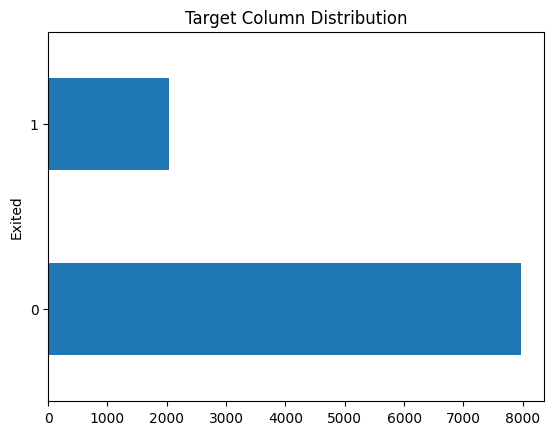

In [14]:
# Understanding target column: Exited (Distribution)

df['Exited'].value_counts().plot(kind = 'barh')
plt.title('Target Column Distribution')
plt.show()

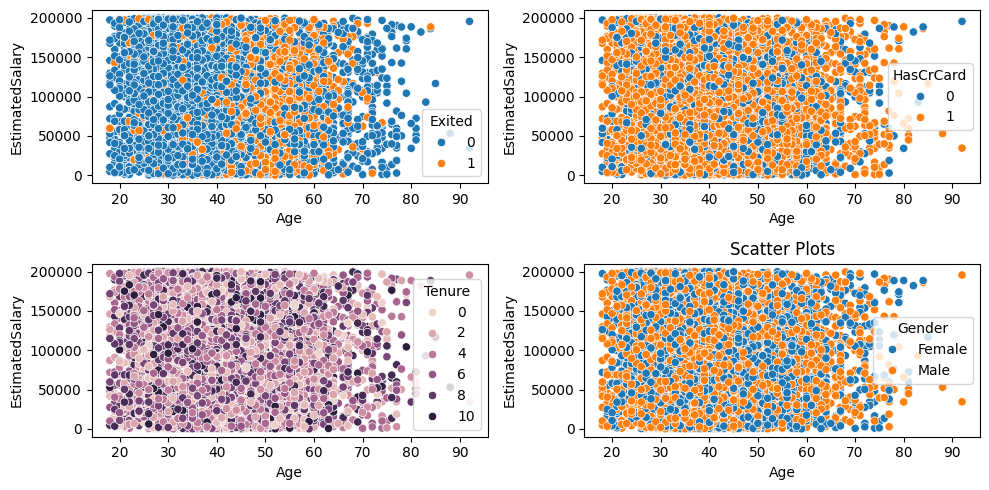

In [15]:
# Plotting function

fig,ax = plt.subplots(2,2,figsize = (10,5))
sns.scatterplot(data = df,x = 'Age',y = 'EstimatedSalary',hue = 'Exited',ax = ax[0][0])
sns.scatterplot(data = df,x = 'Age',y = 'EstimatedSalary',hue = 'HasCrCard',ax = ax[0][1])
sns.scatterplot(data = df,x = 'Age',y = 'EstimatedSalary',hue = 'Tenure',ax = ax[1][0])
sns.scatterplot(data = df,x = 'Age',y = 'EstimatedSalary',hue = 'Gender',ax = ax[1][1])
plt.title('Scatter Plots')
plt.tight_layout()
plt.show()

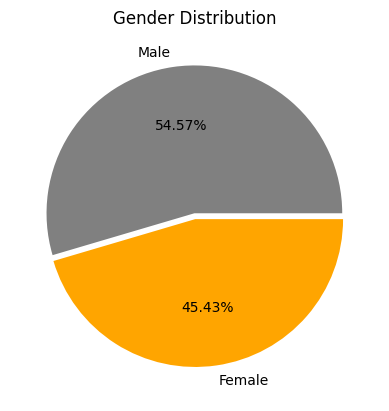

In [16]:
# Gender distribution w.r.t Exited

colors = ['gray', 'orange']

df['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.2f%%',
    explode=[0.02, 0.02],
    colors=colors
)
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()


In [17]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

<Axes: xlabel='Geography', ylabel='Exited'>

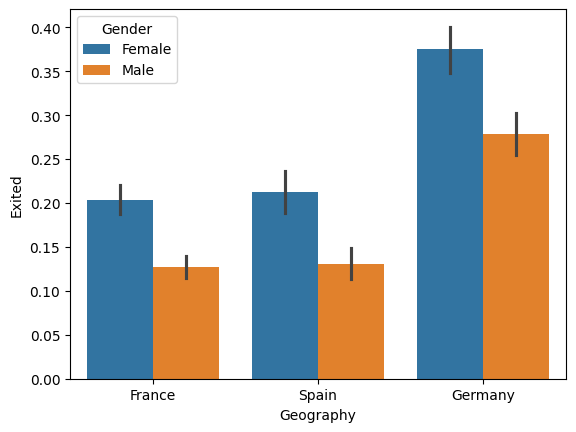

In [18]:
sns.barplot(data=df, x='Geography' , y = 'Exited' , hue= 'Gender' )

<Axes: xlabel='Exited', ylabel='Age'>

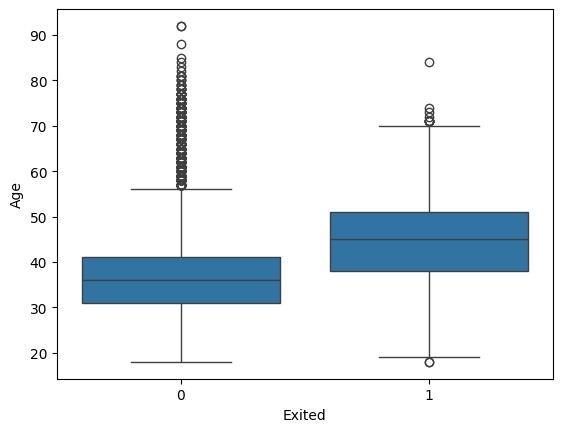

In [19]:
sns.boxplot(df , x= 'Exited' ,y = 'Age')

<Axes: xlabel='IsActiveMember', ylabel='count'>

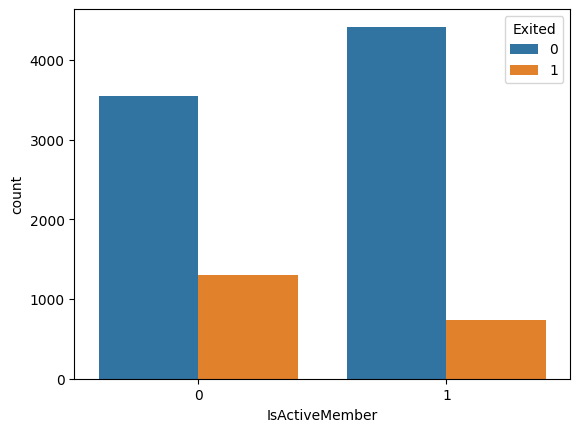

In [20]:
sns.countplot(data= df , x='IsActiveMember' , hue= 'Exited')

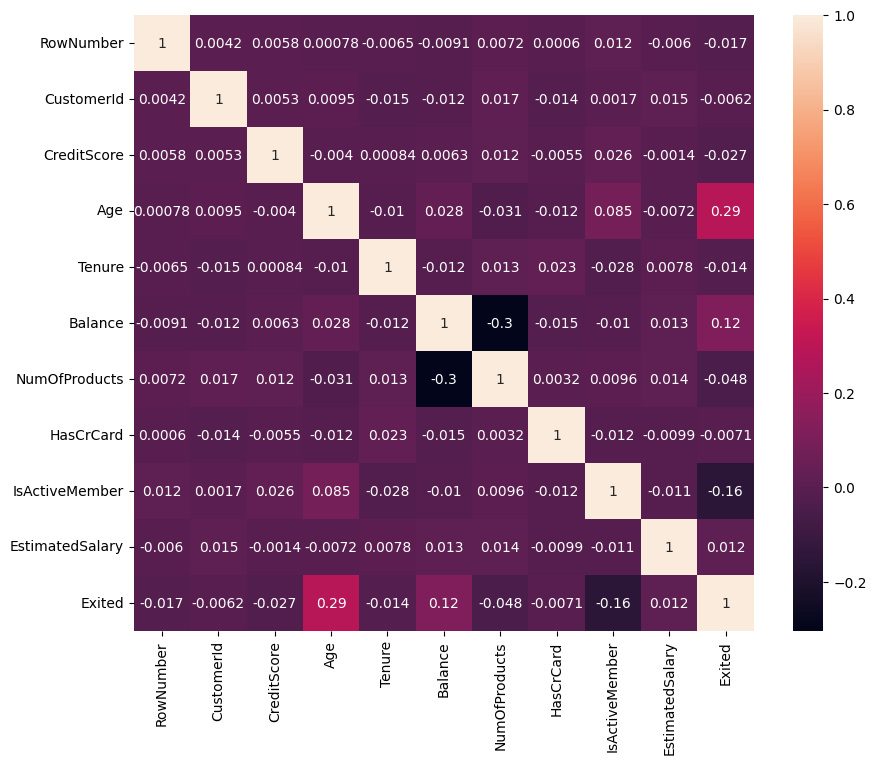

In [21]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only= True) , annot= True)
plt.show()

### Data Insights
1. Data is non-normally distributed
2. Exited is target column
3. There is no missing value in the data
4. There is outlier present in the data so we will use RobustScaler for handling outlier
5. There is imbalance in target columns so we will use SMOTE Technqiue to balance it to get perfect prediction


In [22]:
# Preprocessing function defintion
from sklearn.preprocessing import MinMaxScaler,RobustScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

def preprocessing(df):

  X = df.drop(columns = ['RowNumber', 'CustomerId', 'Surname','Exited'],axis = 1)
  y = df['Exited']

  X_train,X_test,y_train,y_test = train_test_split(X,y,
                                                   test_size = 0.3,
                                                   random_state = 0)

  le = LabelEncoder()

  for i in X_train.columns:
    if X_train[i].dtype == 'object':
      X_train[i] = le.fit_transform(X_train[i])  # fit_train is always with seen Data
      X_test[i] = le.transform(X_test[i])  # transform is always with Unseen Data

  sc = RobustScaler()
  X_train = sc.fit_transform(X_train) # fit_train is always with seen Data
  X_test = sc.transform(X_test)  # transform is always with Unseen Data

  smote = SMOTE() # Using Over Sampling Technique
  X_train,y_train = smote.fit_resample(X_train,y_train) # Balancing Seen Data

  return X_train,X_test,y_train,y_test

In [25]:
# Model building function
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.neighbors import KNeighborsClassifier


def model_build(X_train,X_test,y_train,y_test):

  models = {
      'LogisticRegression': LogisticRegression(),
      'DecisionTreeClassifier': DecisionTreeClassifier(),
      'RandomForestClassifier': RandomForestClassifier(),
      'GradientBoostingClassifier': GradientBoostingClassifier(),
      'AdaBoostClassifier': AdaBoostClassifier(),
      'KNeighborsClassifier': KNeighborsClassifier(n_neighbors= 10)
  }

  model_performance = []

  for model_name,model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)

    report = classification_report(y_test,y_pred)

    report = OrderedDict({
        'Model_Name': model_name,
        'Accuracy_Score': accuracy_score(y_test,y_pred),
        'Confusion_Matrix': confusion_matrix(y_test,y_pred),
        'Classification_Report': report})

    model_performance.append(report)

  model_performance = pd.DataFrame(model_performance)
  return model_performance


In [ ]:
#Function Calling
X_train,X_test,y_train,y_test = preprocessing(df)
model_performance = model_build(X_train,X_test,y_train,y_test)

In [32]:
model_performance

,Model_Name,Accuracy_Score,Confusion_Matrix,Classification_Report
0,LogisticRegression,0.697333,"[[1656, 723], [185, 436]]",precision recall f1-score ...
1,DecisionTreeClassifier,0.767667,"[[1938, 441], [256, 365]]",precision recall f1-score ...
2,RandomForestClassifier,0.844000,"[[2157, 222], [246, 375]]",precision recall f1-score ...
3,GradientBoostingClassifier,0.822667,"[[2040, 339], [193, 428]]",precision recall f1-score ...
4,AdaBoostClassifier,0.796333,"[[1938, 441], [170, 451]]",precision recall f1-score ...
5,KNeighborsClassifier,0.762333,"[[1863, 516], [197, 424]]",precision recall f1-score ...


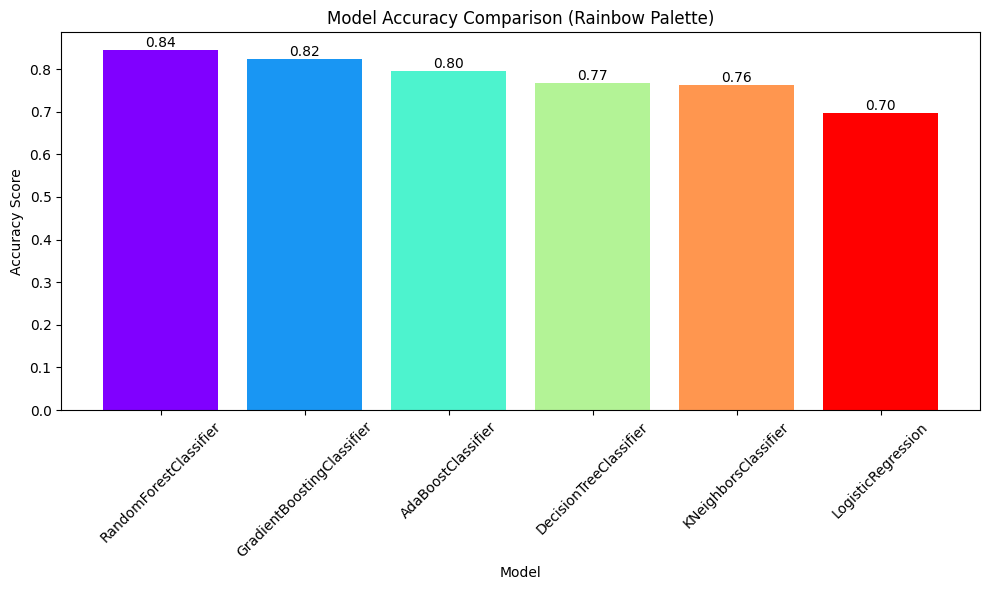

In [ ]:

# Sort by accuracy
sorted_df = model_performance.sort_values(by='Accuracy_Score', ascending=False)
colors = plt.cm.rainbow(np.linspace(0, 1, len(sorted_df)))

plt.figure(figsize=(10, 6))
bars = plt.bar(
    sorted_df['Model_Name'],
    sorted_df['Accuracy_Score'],
    color=colors
)

# Add accuracy values on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha='center',
        va='bottom'
    )

plt.xlabel("Model")
plt.ylabel("Accuracy Score")
plt.title("Model Accuracy Comparison (Rainbow Palette)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Final Report 
* As we can see in above bargarph RandomForestClassifier & GradientBoostingClassifer as highest accuracy so we build model on RandomForestClassifer

